##Mount Google drive with the dataset and load into Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/CAN_project/Car_Hacking_Dataset.zip")
print(zip_path.exists(), zip_path)

True /content/drive/MyDrive/CAN_project/Car_Hacking_Dataset.zip


In [ ]:
data_dir = Path("/content/can_data")

In [ ]:
# Step 4: Inspect extracted files

from pathlib import Path

data_dir = Path("/content/can_data")
for p in data_dir.rglob("*"):
    if p.is_file():
        print(p)

/content/can_data/Fuzzy_dataset.csv
/content/can_data/gear_dataset.csv
/content/can_data/DoS_dataset.csv
/content/can_data/normal_run_data.7z
/content/can_data/RPM_dataset.csv
/content/can_data/normal_run_data/normal_run_data.txt


# CAN Intrusion Detection - Data Loading, Cleaning, and EDA

This notebook loads raw CAN bus datasets from multiple files, standardizes them into a common schema, creates both binary and multiclass labels, performs data cleaning, and runs exploratory data analysis (EDA).

## Files used
- DoS_dataset.csv
- Fuzzy_dataset.csv
- gear_dataset.csv
- RPM_dataset.csv
- normal_run.txt

## Goals
1. Convert all files into one consistent dataframe
2. Create labels for binary and multiclass classification
3. Perform data cleaning
4. Run EDA to understand class balance, CAN ID patterns, DLC patterns, and payload behavior
5. Save cleaned datasets for modeling

In [ ]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Plot settings
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

## Define dataset file paths

This cell points to the raw files already available in the Colab runtime.
If your files are stored in `/content/`, these names should work directly.

In [ ]:
# Define file paths

dos_path = "DoS_dataset.csv"
fuzzy_path = "Fuzzy_dataset.csv"
gear_path = "gear_dataset.csv"
rpm_path = "RPM_dataset.csv"
normal_path = "normal_run.txt"

# Quick check
for f in [dos_path, fuzzy_path, gear_path, rpm_path, normal_path]:
    print(f"{f}: {'Found' if Path(f).exists() else 'Missing'}")

DoS_dataset.csv: Missing
Fuzzy_dataset.csv: Missing
gear_dataset.csv: Missing
RPM_dataset.csv: Missing
normal_run.txt: Missing


## Find the dataset files in the Colab runtime

This cell searches `/content` recursively for the expected files:
- DoS_dataset.csv
- Fuzzy_dataset.csv
- gear_dataset.csv
- RPM_dataset.csv
- normal_run_data.txt

In [ ]:
from pathlib import Path

# Search common runtime locations
search_roots = [Path("/content")]

target_files = {
    "DoS_dataset.csv",
    "Fuzzy_dataset.csv",
    "gear_dataset.csv",
    "RPM_dataset.csv",
    "normal_run_data.txt"
}

found_files = {}

for root in search_roots:
    for p in root.rglob("*"):
        if p.is_file() and p.name in target_files:
            found_files[p.name] = str(p)

print("Found files:")
for k, v in found_files.items():
    print(f"{k}: {v}")

missing = target_files - set(found_files.keys())
print("\nMissing files:")
for m in missing:
    print(m)

Found files:
Fuzzy_dataset.csv: /content/can_data/Fuzzy_dataset.csv
gear_dataset.csv: /content/can_data/gear_dataset.csv
DoS_dataset.csv: /content/can_data/DoS_dataset.csv
RPM_dataset.csv: /content/can_data/RPM_dataset.csv
normal_run_data.txt: /content/can_data/normal_run_data/normal_run_data.txt

Missing files:


## Assign file paths

This cell stores the discovered paths for each dataset file.
It will raise an error if one or more required files are missing.

In [ ]:
# Assign file paths


required = [
    "DoS_dataset.csv",
    "Fuzzy_dataset.csv",
    "gear_dataset.csv",
    "RPM_dataset.csv",
    "normal_run_data.txt"
]

for fname in required:
    if fname not in found_files:
        raise FileNotFoundError(f"{fname} was not found inside /content")

dos_path = found_files["DoS_dataset.csv"]
fuzzy_path = found_files["Fuzzy_dataset.csv"]
gear_path = found_files["gear_dataset.csv"]
rpm_path = found_files["RPM_dataset.csv"]
normal_path = found_files["normal_run_data.txt"]

print("Using paths:")
print(dos_path)
print(fuzzy_path)
print(gear_path)
print(rpm_path)
print(normal_path)

Using paths:
/content/can_data/DoS_dataset.csv
/content/can_data/Fuzzy_dataset.csv
/content/can_data/gear_dataset.csv
/content/can_data/RPM_dataset.csv
/content/can_data/normal_run_data/normal_run_data.txt


## Define the parser for attack datasets

The attack datasets are row-based CAN logs with:
- timestamp
- CAN ID
- DLC
- payload bytes
- direction

If a row has fewer than 8 payload bytes, missing bytes will be padded with `00`.

In [ ]:
# Function to parse attack dataset files

def parse_attack_file(filepath, class_label):
    """
    Parse a raw attack CAN dataset stored as comma-separated values,
    allowing rows with variable numbers of payload bytes.

    Expected general pattern:
    timestamp, can_id, dlc, payload..., direction

    We pad payload bytes to exactly 8 columns.
    """
    rows = []

    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.strip()

            # Skip empty lines
            if not line:
                continue

            parts = [p.strip() for p in line.split(",")]

            # Need at least timestamp, can_id, dlc, direction
            if len(parts) < 4:
                continue

            timestamp = parts[0]
            can_id = parts[1]
            dlc = parts[2]
            direction = parts[-1]

            # Everything between dlc and direction is payload
            payload = parts[3:-1]

            # Pad or trim payload to exactly 8 bytes
            payload = payload[:8] + ["00"] * (8 - len(payload))

            rows.append({
                "timestamp": timestamp,
                "can_id": str(can_id).lower(),
                "dlc": dlc,
                "byte_0": payload[0].lower(),
                "byte_1": payload[1].lower(),
                "byte_2": payload[2].lower(),
                "byte_3": payload[3].lower(),
                "byte_4": payload[4].lower(),
                "byte_5": payload[5].lower(),
                "byte_6": payload[6].lower(),
                "byte_7": payload[7].lower(),
                "direction": str(direction),
                "class_label": class_label,
                "source_file": Path(filepath).name
            })

    return pd.DataFrame(rows)

## Define the parser for the normal CAN log

The normal data uses a different text format, so it requires a separate parser.
This function extracts:
- timestamp
- CAN ID
- DLC
- 8 payload bytes
- class label

In [ ]:
# Function to parse normal CAN log file


def parse_normal_file(filepath):
    """
    Parse normal_run.txt into the same schema as the attack datasets.

    Expected format example:
    Timestamp: 1479121434.850202        ID: 0350    000    DLC: 8    05 28 84 66 6d 00 00 a2
    """
    rows = []

    pattern = re.compile(
        r"Timestamp:\s*([0-9.]+)\s+ID:\s*([0-9A-Fa-f]+)\s+\S+\s+DLC:\s*(\d)\s+(.*)"
    )

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            match = pattern.match(line)
            if not match:
                continue

            timestamp, can_id, dlc, payload_str = match.groups()

            payload = re.split(r"\s+", payload_str.strip())
            payload = payload[:8] + ["00"] * (8 - len(payload))

            rows.append({
                "timestamp": timestamp,
                "can_id": str(can_id).lower(),
                "dlc": dlc,
                "byte_0": payload[0].lower(),
                "byte_1": payload[1].lower(),
                "byte_2": payload[2].lower(),
                "byte_3": payload[3].lower(),
                "byte_4": payload[4].lower(),
                "byte_5": payload[5].lower(),
                "byte_6": payload[6].lower(),
                "byte_7": payload[7].lower(),
                "direction": "unknown",
                "class_label": "normal",
                "source_file": Path(filepath).name
            })

    return pd.DataFrame(rows)

## Load and parse all raw datasets

This cell reads all attack and normal datasets into pandas dataframes.

In [ ]:
# Load all datasets


dos_df = parse_attack_file(dos_path, "DoS")
fuzzy_df = parse_attack_file(fuzzy_path, "Fuzzy")
gear_df = parse_attack_file(gear_path, "gear")
rpm_df = parse_attack_file(rpm_path, "RPM")
normal_df = parse_normal_file(normal_path)

print("DoS shape:   ", dos_df.shape)
print("Fuzzy shape: ", fuzzy_df.shape)
print("Gear shape:  ", gear_df.shape)
print("RPM shape:   ", rpm_df.shape)
print("Normal shape:", normal_df.shape)

DoS shape:    (3665771, 14)
Fuzzy shape:  (3838860, 14)
Gear shape:   (4443142, 14)
RPM shape:    (4621702, 14)
Normal shape: (988871, 14)


In [ ]:
# Preview the corrected attack dataset
dos_df.head()

,timestamp,can_id,dlc,byte_0,byte_1,byte_2,byte_3,byte_4,byte_5,byte_6,byte_7,direction,class_label,source_file
0,1478198376.389427,0316,8,05,21,68,09,21,21,00,6f,R,DoS,DoS_dataset.csv
1,1478198376.389636,018f,8,fe,5b,00,00,00,3c,00,00,R,DoS,DoS_dataset.csv
2,1478198376.389864,0260,8,19,21,22,30,08,8e,6d,3a,R,DoS,DoS_dataset.csv
3,1478198376.390096,02a0,8,64,00,9a,1d,97,02,bd,00,R,DoS,DoS_dataset.csv
4,1478198376.390333,0329,8,40,bb,7f,14,11,20,00,14,R,DoS,DoS_dataset.csv


## load the normal dataset

This uses the previously defined parser for the normal CAN log text file.

In [ ]:
normal_df = parse_normal_file(normal_path)

print("Normal shape:", normal_df.shape)
normal_df.head()

Normal shape: (988871, 14)


,timestamp,can_id,dlc,byte_0,byte_1,byte_2,byte_3,byte_4,byte_5,byte_6,byte_7,direction,class_label,source_file
0,1479121434.850202,0350,8,05,28,84,66,6d,00,00,a2,unknown,normal,normal_run_data.txt
1,1479121434.850423,02c0,8,14,00,00,00,00,00,00,00,unknown,normal,normal_run_data.txt
2,1479121434.850977,0430,8,00,00,00,00,00,00,00,00,unknown,normal,normal_run_data.txt
3,1479121434.851215,04b1,8,00,00,00,00,00,00,00,00,unknown,normal,normal_run_data.txt
4,1479121434.851463,01f1,8,00,00,00,00,00,00,00,00,unknown,normal,normal_run_data.txt


## Combine all datasets

We now merge the normal and attack data into one master dataframe and create:
- `class_label` for multiclass classification
- `binary_label` for normal vs attack classification

In [ ]:
# Combine all datasets


all_df = pd.concat(
    [normal_df, dos_df, fuzzy_df, gear_df, rpm_df],
    ignore_index=True
)

# Binary label
all_df["binary_label"] = np.where(all_df["class_label"] == "normal", "normal", "attack")

print("Combined dataframe shape:", all_df.shape)
all_df.head()

Combined dataframe shape: (17558346, 15)


,timestamp,can_id,dlc,byte_0,byte_1,byte_2,byte_3,byte_4,byte_5,byte_6,byte_7,direction,class_label,source_file,binary_label
0,1479121434.850202,0350,8,05,28,84,66,6d,00,00,a2,unknown,normal,normal_run_data.txt,normal
1,1479121434.850423,02c0,8,14,00,00,00,00,00,00,00,unknown,normal,normal_run_data.txt,normal
2,1479121434.850977,0430,8,00,00,00,00,00,00,00,00,unknown,normal,normal_run_data.txt,normal
3,1479121434.851215,04b1,8,00,00,00,00,00,00,00,00,unknown,normal,normal_run_data.txt,normal
4,1479121434.851463,01f1,8,00,00,00,00,00,00,00,00,unknown,normal,normal_run_data.txt,normal


## Convert columns to usable data types

This step converts:
- timestamp to numeric
- DLC to integer
- CAN ID to integer form
- payload bytes from hex strings to integers

In [ ]:
# Convert data types and store them in a new data frame for EDA purposes

df_eda = all_df.copy()

def hex_to_int(x):
    """
    Convert a hex-like string to integer.
    Returns NaN if conversion fails.
    """
    try:
        return int(str(x), 16)
    except:
        return np.nan

# Convert timestamp and dlc
df_eda["timestamp"] = pd.to_numeric(df_eda["timestamp"], errors="coerce")
df_eda["dlc"] = pd.to_numeric(df_eda["dlc"], errors="coerce")

# Convert can_id to integer
df_eda["can_id_int"] = df_eda["can_id"].apply(hex_to_int)

# Convert payload bytes
byte_cols = [f"byte_{i}" for i in range(8)]

for col in byte_cols:
    df_eda[col] = df_eda[col].astype(str).str.lower()
    df_eda[col + "_int"] = df_eda[col].apply(hex_to_int)

df_eda.head()

,timestamp,can_id,dlc,byte_0,byte_1,byte_2,byte_3,byte_4,byte_5,byte_6,byte_7,direction,class_label,source_file,binary_label,can_id_int,byte_0_int,byte_1_int,byte_2_int,byte_3_int,byte_4_int,byte_5_int,byte_6_int,byte_7_int
0,1.479121e+09,0350,8,05,28,84,66,6d,00,00,a2,unknown,normal,normal_run_data.txt,normal,848,5,40,132,102,109,0,0,162
1,1.479121e+09,02c0,8,14,00,00,00,00,00,00,00,unknown,normal,normal_run_data.txt,normal,704,20,0,0,0,0,0,0,0
2,1.479121e+09,0430,8,00,00,00,00,00,00,00,00,unknown,normal,normal_run_data.txt,normal,1072,0,0,0,0,0,0,0,0
3,1.479121e+09,04b1,8,00,00,00,00,00,00,00,00,unknown,normal,normal_run_data.txt,normal,1201,0,0,0,0,0,0,0,0
4,1.479121e+09,01f1,8,00,00,00,00,00,00,00,00,unknown,normal,normal_run_data.txt,normal,497,0,0,0,0,0,0,0,0


## Initial data quality checks

We inspect:
- missing values
- duplicates
- DLC distribution
- invalid byte conversions

In [ ]:
df_eda.drop(columns=["can_id","byte_0","byte_1","byte_2","byte_3","byte_4","byte_5","byte_6", "byte_7"], inplace=True)

In [ ]:
df_eda.head()

,timestamp,dlc,direction,class_label,source_file,binary_label,can_id_int,byte_0_int,byte_1_int,byte_2_int,byte_3_int,byte_4_int,byte_5_int,byte_6_int,byte_7_int
0,1.479121e+09,8,unknown,normal,normal_run_data.txt,normal,848,5,40,132,102,109,0,0,162
1,1.479121e+09,8,unknown,normal,normal_run_data.txt,normal,704,20,0,0,0,0,0,0,0
2,1.479121e+09,8,unknown,normal,normal_run_data.txt,normal,1072,0,0,0,0,0,0,0,0
3,1.479121e+09,8,unknown,normal,normal_run_data.txt,normal,1201,0,0,0,0,0,0,0,0
4,1.479121e+09,8,unknown,normal,normal_run_data.txt,normal,497,0,0,0,0,0,0,0,0


In [ ]:
#df_eda.drop(columns=['source_file'],inplace=True)

In [ ]:
# Initial quality checks

print("Missing values per column:\n")
print(df_eda.isna().sum())

print("\nNumber of duplicate rows:", df_eda.duplicated().sum())

print("\nDLC distribution:\n")
print(df_eda["dlc"].value_counts().sort_index())

Missing values per column:

timestamp       0
dlc             0
direction       0
class_label     0
source_file     0
binary_label    0
can_id_int      0
byte_0_int      0
byte_1_int      0
byte_2_int      0
byte_3_int      0
byte_4_int      0
byte_5_int      0
byte_6_int      0
byte_7_int      0
dtype: int64

Number of duplicate rows: 0

DLC distribution:

dlc
2      157340
5      104057
6           3
8    17296946
Name: count, dtype: int64


In [ ]:
# Check invalid payload byte conversions
invalid_byte_counts = df_eda[[c + "_int" for c in byte_cols]].isna().sum()

print("Invalid payload byte conversions:\n")
print(invalid_byte_counts)

Invalid payload byte conversions:

byte_0_int    0
byte_1_int    0
byte_2_int    0
byte_3_int    0
byte_4_int    0
byte_5_int    0
byte_6_int    0
byte_7_int    0
dtype: int64


## Clean the dataset

We:
- remove exact duplicates,
- keep only valid DLC values between 0 and 8,
- remove rows missing timestamp or CAN ID.

In [ ]:
# Data cleaning

df_eda = df_eda.drop_duplicates().copy()
df_eda = df_eda[(df_eda["dlc"] >= 0) & (df_eda["dlc"] <= 8)].copy()
df_eda = df_eda.dropna(subset=["timestamp", "can_id_int"]).copy()

print("Shape after cleaning:", df_eda.shape)

Shape after cleaning: (17558346, 15)


## Create helper features for EDA

These helper features help explore:
- timing behavior,
- payload structure,
- message characteristics.

In [ ]:
# Create helper features for EDA

# Sort within each file before time-based calculations
df_eda = df_eda.sort_values(["source_file", "timestamp"]).reset_index(drop=True)

# Inter-arrival time within each source file
df_eda["inter_arrival"] = df_eda.groupby("source_file")["timestamp"].diff()

# Simple payload summary features
df_eda["payload_sum"] = df_eda[[c + "_int" for c in byte_cols]].sum(axis=1)
df_eda["nonzero_bytes"] = (df_eda[[c + "_int" for c in byte_cols]] != 0).sum(axis=1)
df_eda["payload_unique_values"] = df_eda[[c + "_int" for c in byte_cols]].nunique(axis=1)

df_eda.head()

,timestamp,dlc,direction,class_label,source_file,binary_label,can_id_int,byte_0_int,byte_1_int,byte_2_int,byte_3_int,byte_4_int,byte_5_int,byte_6_int,byte_7_int,inter_arrival,payload_sum,nonzero_bytes,payload_unique_values
0,1.478198e+09,8,R,DoS,DoS_dataset.csv,attack,790,5,33,104,9,33,33,0,111,NaN,328,7,6
1,1.478198e+09,8,R,DoS,DoS_dataset.csv,attack,399,254,91,0,0,0,60,0,0,0.000209,405,3,4
2,1.478198e+09,8,R,DoS,DoS_dataset.csv,attack,608,25,33,34,48,8,142,109,58,0.000228,457,8,8
3,1.478198e+09,8,R,DoS,DoS_dataset.csv,attack,672,100,0,154,29,151,2,189,0,0.000232,625,6,7
4,1.478198e+09,8,R,DoS,DoS_dataset.csv,attack,809,64,187,127,20,17,32,0,20,0.000237,467,7,7


## EDA 1: Class distribution

This shows the class balance for:
- binary classification
- multiclass classification

Binary class distribution:

binary_label
attack    16569475
normal      988871
Name: count, dtype: int64


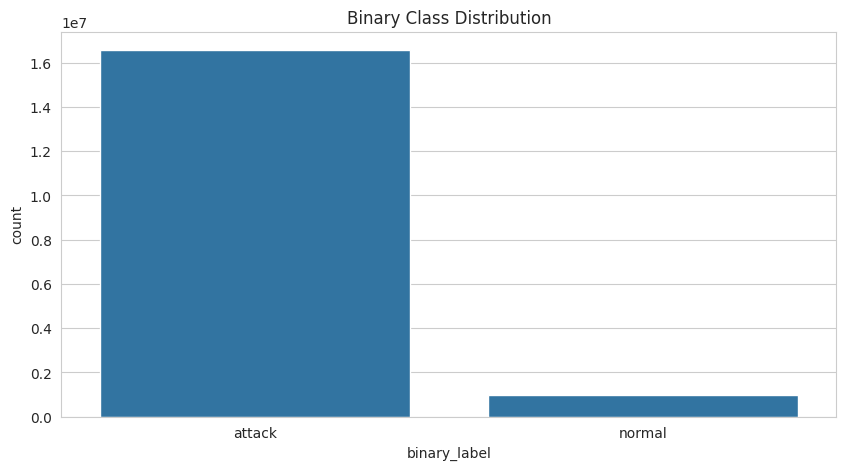

In [ ]:
print("Binary class distribution:\n")
print(df_eda["binary_label"].value_counts())

sns.countplot(data=df_eda, x="binary_label")
plt.title("Binary Class Distribution")
plt.show()

Multiclass class distribution:

class_label
RPM       4621702
gear      4443142
Fuzzy     3838860
DoS       3665771
normal     988871
Name: count, dtype: int64


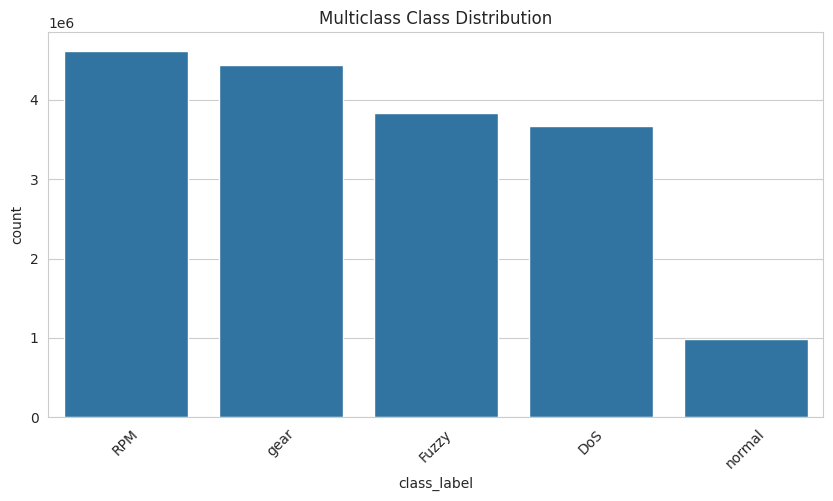

In [ ]:
print("Multiclass class distribution:\n")
print(df_eda["class_label"].value_counts())

sns.countplot(
    data=df_eda,
    x="class_label",
    order=df_eda["class_label"].value_counts().index
)
plt.title("Multiclass Class Distribution")
plt.xticks(rotation=45)
plt.show()

## EDA 2: CAN ID frequency analysis

This examines:
- the most frequent CAN IDs,
- whether certain IDs dominate specific classes.

Top 15 CAN IDs:

can_id_int
790     1481995
1087    1415099
399      826837
2        824469
339      820845
608      820526
704      819616
304      818072
880      817226
672      816575
848      815969
305      811777
320      808703
809      808596
1088     805974
Name: count, dtype: int64


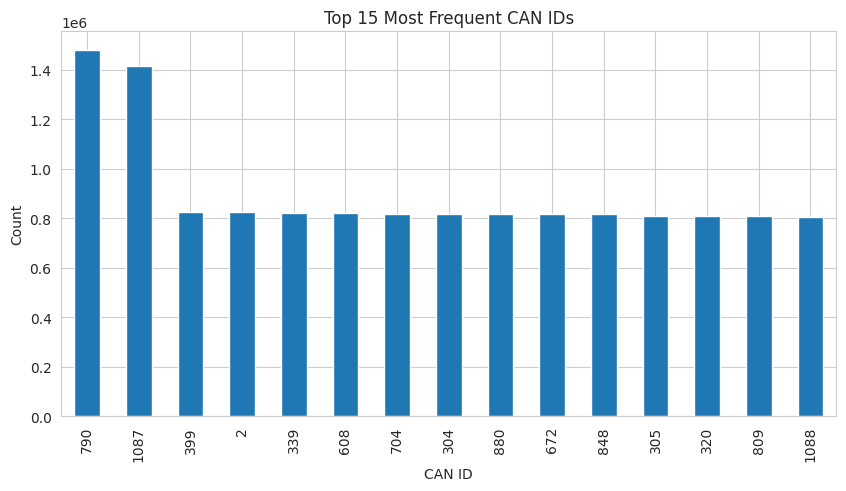

In [ ]:
top_ids = df_eda["can_id_int"].value_counts().head(15)

print("Top 15 CAN IDs:\n")
print(top_ids)

top_ids.plot(kind="bar")
plt.title("Top 15 Most Frequent CAN IDs")
plt.xlabel("CAN ID")
plt.ylabel("Count")
plt.show()

In [ ]:
canid_by_class = (
    df_eda.groupby(["class_label", "can_id_int"])
    .size()
    .reset_index(name="count")
    .sort_values(["class_label", "count"], ascending=[True, False])
)

canid_by_class.head(20)

,class_label,can_id_int,count
0,DoS,0,587521
4,DoS,304,168118
1,DoS,2,167556
5,DoS,305,167016
6,DoS,320,167002
8,DoS,399,166931
12,DoS,704,166713
16,DoS,880,166681
13,DoS,790,166631
7,DoS,339,166573


## EDA 3: DLC distribution

This checks whether DLC patterns differ across classes.

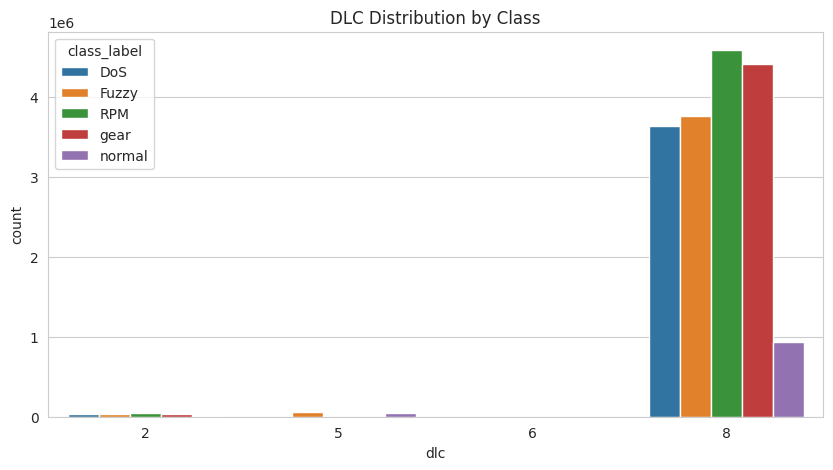

In [ ]:
sns.countplot(data=df_eda, x="dlc", hue="class_label")
plt.title("DLC Distribution by Class")
plt.show()

## EDA 4: Inter-arrival time analysis

Timing behavior can help distinguish normal traffic from attack traffic.

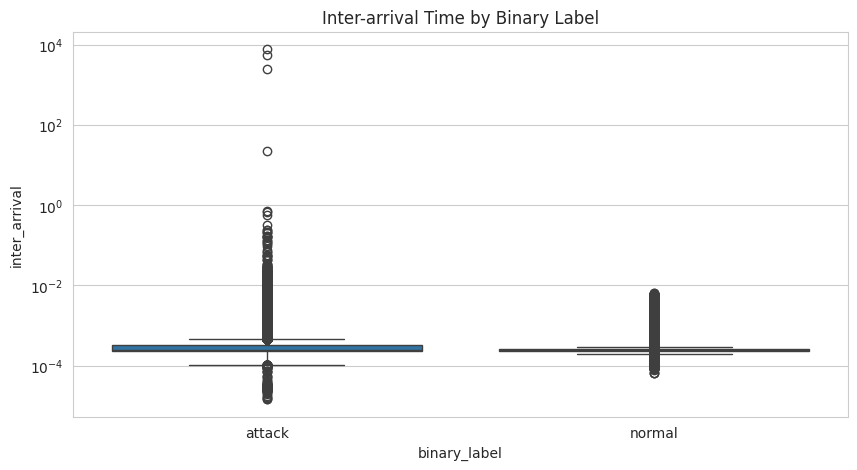

In [ ]:
iat_df = df_eda[(df_eda["inter_arrival"].notna()) & (df_eda["inter_arrival"] >= 0)].copy()

sns.boxplot(data=iat_df, x="binary_label", y="inter_arrival")
plt.title("Inter-arrival Time by Binary Label")
plt.yscale("log")
plt.show()

## EDA 5: Payload behavior

These plots compare simple payload-based summaries between normal and attack traffic:
- payload sum
- non-zero bytes
- unique payload values

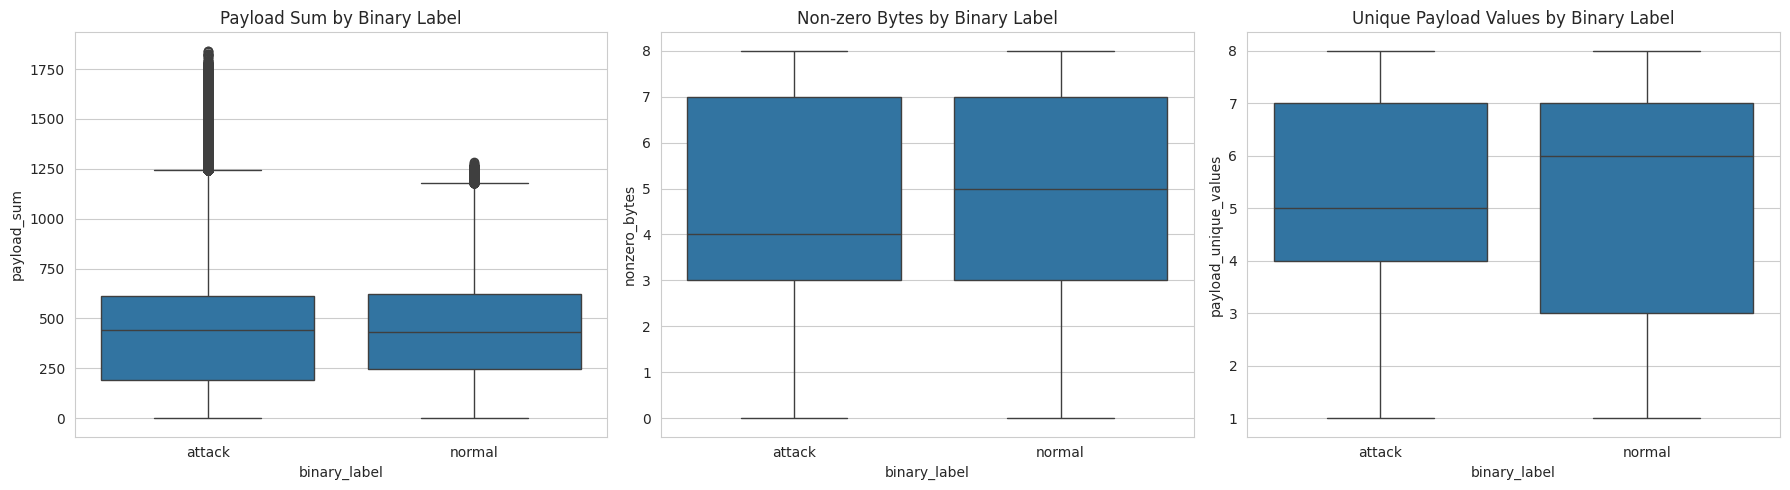

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_eda, x="binary_label", y="payload_sum", ax=axes[0])
axes[0].set_title("Payload Sum by Binary Label")

sns.boxplot(data=df_eda, x="binary_label", y="nonzero_bytes", ax=axes[1])
axes[1].set_title("Non-zero Bytes by Binary Label")

sns.boxplot(data=df_eda, x="binary_label", y="payload_unique_values", ax=axes[2])
axes[2].set_title("Unique Payload Values by Binary Label")

plt.tight_layout()
plt.show()

## EDA 6: Correlation heatmap

This heatmap shows relationships among numeric and engineered helper features.

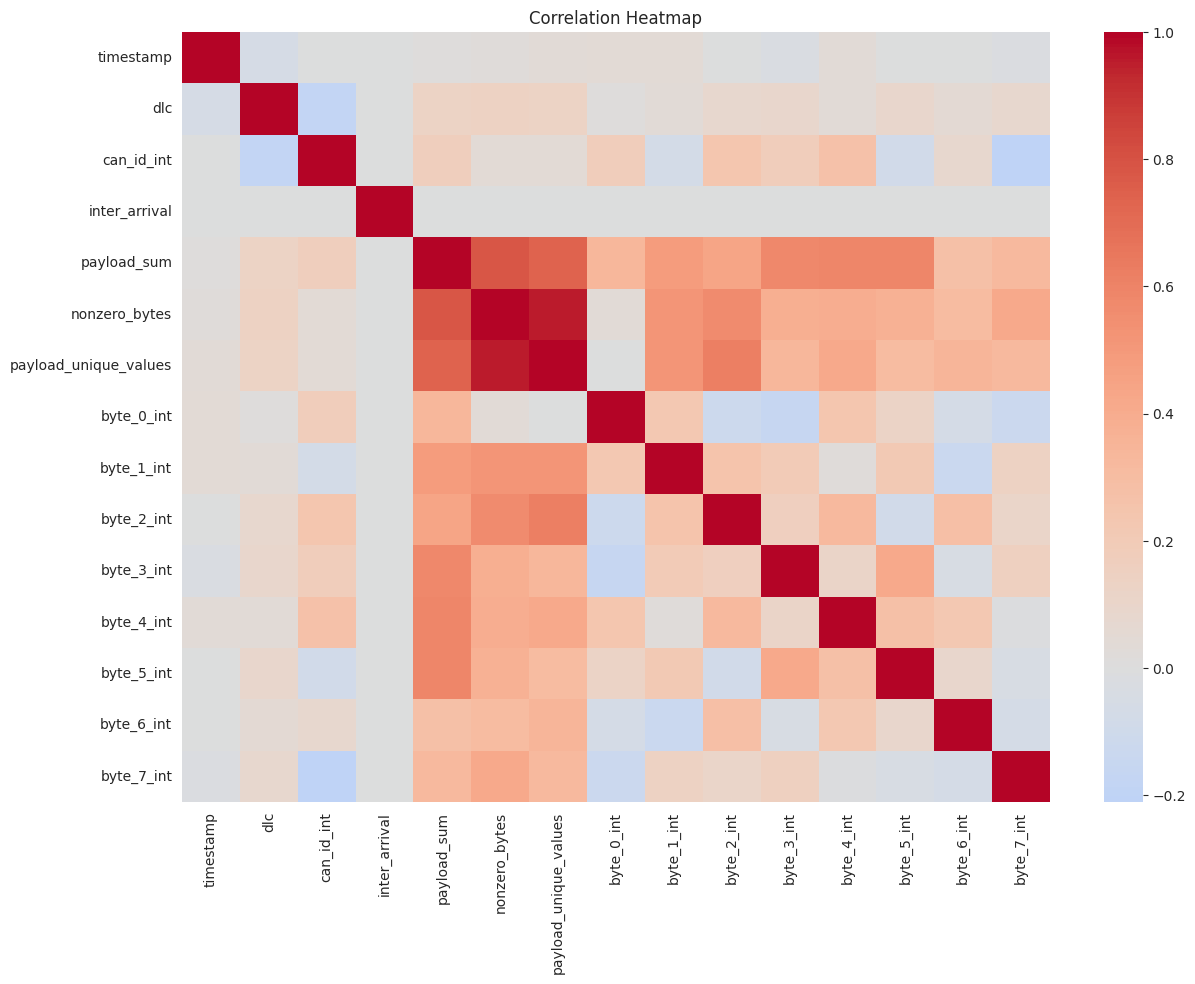

In [ ]:
numeric_cols = [
    "timestamp", "dlc", "can_id_int", "inter_arrival",
    "payload_sum", "nonzero_bytes", "payload_unique_values"
] + [c + "_int" for c in byte_cols]

corr_df = df_eda[numeric_cols].copy()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Create final binary and multiclass datasets

These datasets will be used later for:
- feature engineering,
- train/validation/test split,
- baseline model training.

In [ ]:
binary_df = df_eda.copy()
multiclass_df = df_eda.copy()

# Binary target
binary_df["binary_target"] = binary_df["binary_label"].map({
    "normal": 0,
    "attack": 1
})

# Multiclass target
class_mapping = {
    "normal": 0,
    "DoS": 1,
    "Fuzzy": 2,
    "gear": 3,
    "RPM": 4
}

multiclass_df["multiclass_target"] = multiclass_df["class_label"].map(class_mapping)

print("Class mapping:")
print(class_mapping)

Class mapping:
{'normal': 0, 'DoS': 1, 'Fuzzy': 2, 'gear': 3, 'RPM': 4}


## Save cleaned datasets

This saves cleaned binary and multiclass datasets for later modeling.

In [ ]:
binary_df.to_csv("can_binary_cleaned.csv", index=False)
multiclass_df.to_csv("can_multiclass_cleaned.csv", index=False)

print("Saved files:")
print("- can_binary_cleaned.csv")
print("- can_multiclass_cleaned.csv")

Saved files:
- can_binary_cleaned.csv
- can_multiclass_cleaned.csv


<!-- from google.colab import files

files.download("can_binary_cleaned.csv")
files.download("can_multiclass_cleaned.csv") -->